In [ ]:
#Nome: Tárcila Jéssica Silva de Sousa

### Import all packages need in the cell below

In [ ]:
using JuMP
using HiGHS

In [4]:
using Pkg
Pkg.add("Plots")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Manifest.toml`


# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

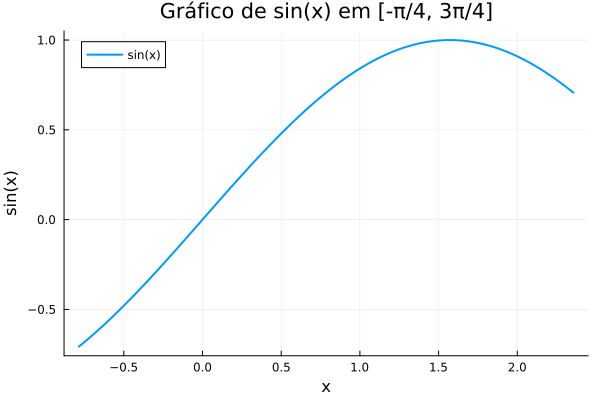

In [5]:
using Plots

x = range(-π/4, 3π/4, length=500)
y = sin.(x)

plot(x, y,
    label = "sin(x)",
    xlabel = "x",
    ylabel = "sin(x)",
    title = "Gráfico de sin(x) em [-π/4, 3π/4]",
    lw = 2
)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

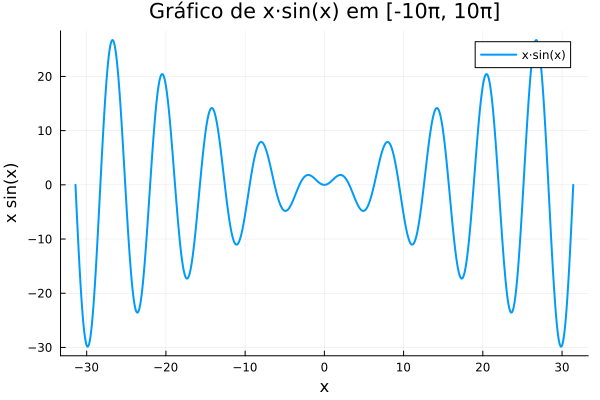

In [7]:
using Plots

x = range(-10π, 10π, length=1000)
y = x .* sin.(x)

plot(x, y,
    label = "x·sin(x)",
    xlabel = "x",
    ylabel = "x sin(x)",
    title = "Gráfico de x·sin(x) em [-10π, 10π]",
    lw = 2
)

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [7]:
import Pkg
Pkg.add("JuMP")
Pkg.add("Ipopt")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Manifest.toml`


In [6]:
using JuMP, Ipopt

model = Model(Ipopt.Optimizer)

@variable(model, r >= 0)
@variable(model, h >= 0)

@NLobjective(model, Max,
    10 * pi * r^2 * h
    - 2 * pi * r^2
    - 0.5 * pi^2 * r^2 * h * (r^2 + 2 * r * h)
)

optimize!(model)

r_opt = value(r)
h_opt = value(h)
z_opt = objective_value(model)
V = pi * r_opt^2 * h_opt

println("r = ", r_opt)
println("h = ", h_opt)
println("z = ", z_opt)
println("Volume = ", V)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -5.9690292e-04 0.00e+00 1.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [7]:
using JuMP
import Ipopt

modelo = Model(Ipopt.Optimizer)

@variable(modelo, x >= 3.0001, start = 5.0)
@variable(modelo, y >= 0.0, start = 5.0)

# Minimiza o comprimento ao quadrado
@objective(modelo, Min, x^2 + y^2)

# Restrição do problema
@constraint(modelo, y * (x - 3) >= 2x)

optimize!(modelo)

println("status = ", termination_status(modelo))
println("x = ", round(value(x), digits=4))
println("y = ", round(value(y), digits=4))
println("comprimento = ", round(sqrt(value(x)^2 + value(y)^2), digits=4))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        4
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.0000000e+01 0.00e+00 2.43e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Packing Problem

In [ ]:
# code

# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

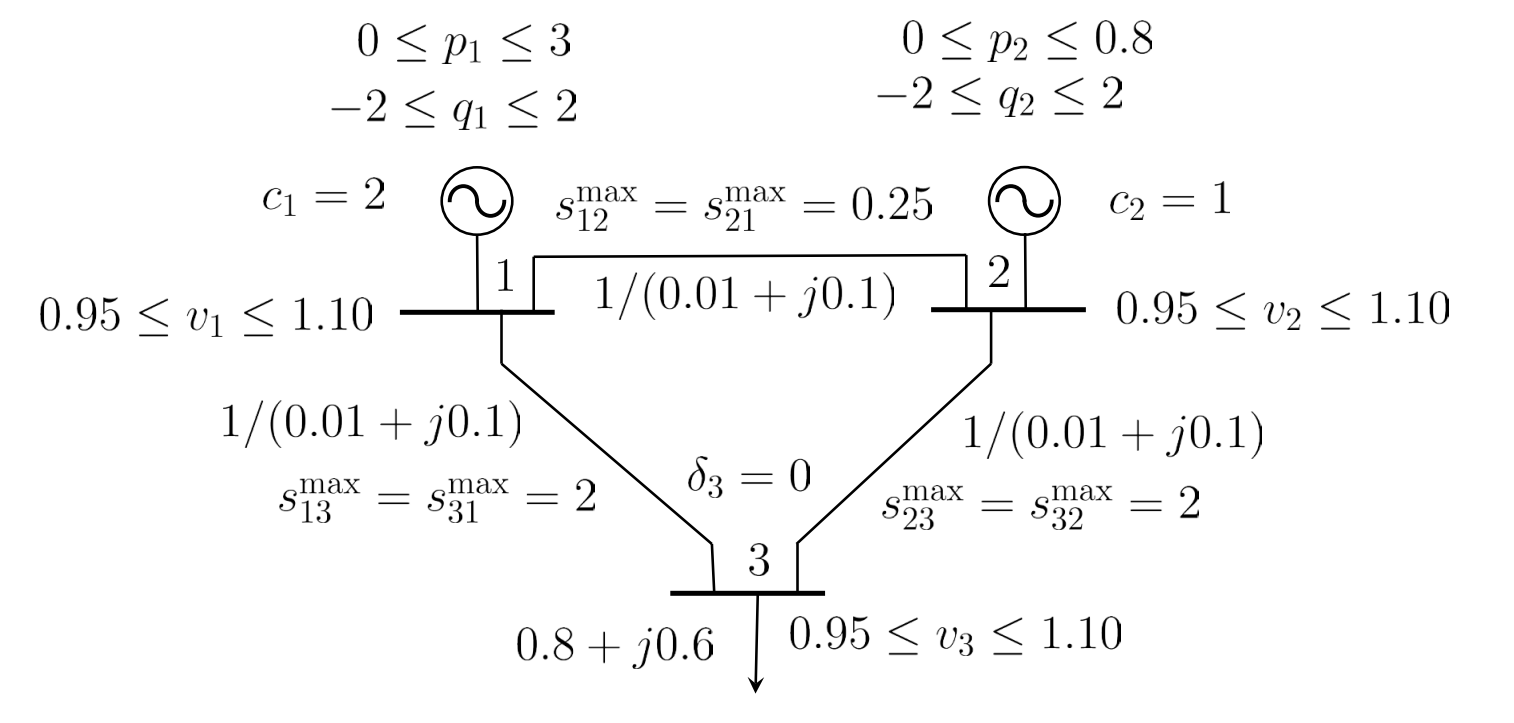

In [11]:
using JuMP
using Ipopt

# Se precisar instalar:
# using Pkg
# Pkg.add("JuMP")
# Pkg.add("Ipopt")

# DADOS DO PROBLEMA

z = 0.01 + 0.1im
y = 1 / z

g = real(y)
b = imag(y)

Pd3 = 0.8
Qd3 = 0.6

Smax12 = 0.25
Smax13 = 2.0
Smax23 = 2.0

# Matriz Ybus = G + jB
G = [
    2g   -g   -g
    -g   2g   -g
    -g   -g   2g
]

B = [
    2b   -b   -b
    -b   2b   -b
    -b   -b   2b
]

# Valores iniciais
v0 = [1.09, 1.10, 1.06]
d0 = [0.02, 0.04, 0.0]


# MODELO

modelo = Model(Ipopt.Optimizer)
set_optimizer_attribute(modelo, "print_level", 0)

# Geração
@variable(modelo, 0 <= p1 <= 3, start = 0.05)
@variable(modelo, -2 <= q1 <= 2, start = 0.30)

@variable(modelo, 0 <= p2 <= 0.8, start = 0.75)
@variable(modelo, -2 <= q2 <= 2, start = 0.30)

# Tensões
@variable(modelo, 0.95 <= v[i=1:3] <= 1.10, start = v0[i])

# Ângulos
@variable(modelo, delta[i=1:3], start = d0[i])
fix(delta[3], 0.0; force = true)


# INJEÇÕES DE POTÊNCIA NAS BARRAS

@NLexpression(modelo, Pcalc[i=1:3],
    sum(
        v[i] * v[j] * (
            G[i,j] * cos(delta[i] - delta[j]) +
            B[i,j] * sin(delta[i] - delta[j])
        )
        for j in 1:3
    )
)

@NLexpression(modelo, Qcalc[i=1:3],
    sum(
        v[i] * v[j] * (
            G[i,j] * sin(delta[i] - delta[j]) -
            B[i,j] * cos(delta[i] - delta[j])
        )
        for j in 1:3
    )
)

# Balanço de potência
@NLconstraint(modelo, Pcalc[1] == p1)
@NLconstraint(modelo, Qcalc[1] == q1)

@NLconstraint(modelo, Pcalc[2] == p2)
@NLconstraint(modelo, Qcalc[2] == q2)

@NLconstraint(modelo, Pcalc[3] == -Pd3)
@NLconstraint(modelo, Qcalc[3] == -Qd3)


# FLUXOS NAS LINHAS

# Linha 1-2
@NLexpression(modelo, P12,
    g * v[1]^2 - v[1] * v[2] * (
        g * cos(delta[1] - delta[2]) +
        b * sin(delta[1] - delta[2])
    )
)

@NLexpression(modelo, Q12,
    -b * v[1]^2 - v[1] * v[2] * (
        g * sin(delta[1] - delta[2]) -
        b * cos(delta[1] - delta[2])
    )
)

@NLexpression(modelo, P21,
    g * v[2]^2 - v[2] * v[1] * (
        g * cos(delta[2] - delta[1]) +
        b * sin(delta[2] - delta[1])
    )
)

@NLexpression(modelo, Q21,
    -b * v[2]^2 - v[2] * v[1] * (
        g * sin(delta[2] - delta[1]) -
        b * cos(delta[2] - delta[1])
    )
)

# Linha 1-3
@NLexpression(modelo, P13,
    g * v[1]^2 - v[1] * v[3] * (
        g * cos(delta[1] - delta[3]) +
        b * sin(delta[1] - delta[3])
    )
)

@NLexpression(modelo, Q13,
    -b * v[1]^2 - v[1] * v[3] * (
        g * sin(delta[1] - delta[3]) -
        b * cos(delta[1] - delta[3])
    )
)

@NLexpression(modelo, P31,
    g * v[3]^2 - v[3] * v[1] * (
        g * cos(delta[3] - delta[1]) +
        b * sin(delta[3] - delta[1])
    )
)

@NLexpression(modelo, Q31,
    -b * v[3]^2 - v[3] * v[1] * (
        g * sin(delta[3] - delta[1]) -
        b * cos(delta[3] - delta[1])
    )
)

# Linha 2-3
@NLexpression(modelo, P23,
    g * v[2]^2 - v[2] * v[3] * (
        g * cos(delta[2] - delta[3]) +
        b * sin(delta[2] - delta[3])
    )
)

@NLexpression(modelo, Q23,
    -b * v[2]^2 - v[2] * v[3] * (
        g * sin(delta[2] - delta[3]) -
        b * cos(delta[2] - delta[3])
    )
)

@NLexpression(modelo, P32,
    g * v[3]^2 - v[3] * v[2] * (
        g * cos(delta[3] - delta[2]) +
        b * sin(delta[3] - delta[2])
    )
)

@NLexpression(modelo, Q32,
    -b * v[3]^2 - v[3] * v[2] * (
        g * sin(delta[3] - delta[2]) -
        b * cos(delta[3] - delta[2])
    )
)


# LIMITES DE FLUXO APARENTE

@NLconstraint(modelo, P12^2 + Q12^2 <= Smax12^2)
@NLconstraint(modelo, P21^2 + Q21^2 <= Smax12^2)

@NLconstraint(modelo, P13^2 + Q13^2 <= Smax13^2)
@NLconstraint(modelo, P31^2 + Q31^2 <= Smax13^2)

@NLconstraint(modelo, P23^2 + Q23^2 <= Smax23^2)
@NLconstraint(modelo, P32^2 + Q32^2 <= Smax23^2)

# FUNÇÃO OBJETIVO

@objective(modelo, Min, 2 * p1 + p2)

optimize!(modelo)

# RESULTADOS:

println("STATUS")
println("Termination status = ", termination_status(modelo))
println()

println("FUNÇÃO OBJETIVO")
println("Custo ótimo = ", objective_value(modelo))
println()

println("GERAÇÃO")
println("p1 = ", value(p1))
println("q1 = ", value(q1))
println("p2 = ", value(p2))
println("q2 = ", value(q2))
println()

println("TENSÕES")
println("v1 = ", value(v[1]))
println("v2 = ", value(v[2]))
println("v3 = ", value(v[3]))
println()

println("ÂNGULOS")
println("delta1 (rad)   = ", value(delta[1]))
println("delta2 (rad)   = ", value(delta[2]))
println("delta3 (rad)   = ", value(delta[3]))
println("delta1 (graus) = ", rad2deg(value(delta[1])))
println("delta2 (graus) = ", rad2deg(value(delta[2])))
println("delta3 (graus) = ", rad2deg(value(delta[3])))
println()

println("FLUXOS APARENTES")
println("|S12| = ", sqrt(value(P12)^2 + value(Q12)^2))
println("|S21| = ", sqrt(value(P21)^2 + value(Q21)^2))
println("|S13| = ", sqrt(value(P13)^2 + value(Q13)^2))
println("|S31| = ", sqrt(value(P31)^2 + value(Q31)^2))
println("|S23| = ", sqrt(value(P23)^2 + value(Q23)^2))
println("|S32| = ", sqrt(value(P32)^2 + value(Q32)^2))
println()

println("PERDAS ATIVAS")
perdas_ativas = value(p1) + value(p2) - Pd3
println("Perdas ativas = ", perdas_ativas)
println()

println("CHECAGEM DOS LIMITES")
println("Limite linha 1-2: ", Smax12)
println("Limite linha 1-3: ", Smax13)
println("Limite linha 2-3: ", Smax23)


STATUS
Termination status = LOCALLY_SOLVED

FUNÇÃO OBJETIVO
Custo ótimo = 0.8360786945615205

GERAÇÃO
p1 = 0.030906834553261108
q1 = 0.3209166923859717
p2 = 0.7742650254549983
q2 = 0.3308019076966289

TENSÕES
v1 = 1.0977001927052608
v2 = 1.0999998938295108
v3 = 1.0663591316422725

ÂNGULOS
delta1 (rad)   = 0.0212319668820324
delta2 (rad)   = 0.041912659955651875
delta3 (rad)   = 0.0
delta1 (graus) = 1.2165020931019943
delta2 (graus) = 2.4014185236258245
delta3 (graus) = 0.0

FLUXOS APARENTES
|S12| = 0.24947735886869682
|S21| = 0.25000001830383
|S13| = 0.42442390470835145
|S31| = 0.4123059369768537
|S23| = 0.6183879970056274
|S32| = 0.5994761374105436

PERDAS ATIVAS
Perdas ativas = 0.005171860008259421

CHECAGEM DOS LIMITES
Limite linha 1-2: 0.25
Limite linha 1-3: 2.0
Limite linha 2-3: 2.0


# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [13]:
using LinearAlgebra
using Printf

# Dados do problema

x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
y  = [2.0, 3.9, 6.1, 8.0, 9.8]

# Montando a matriz do modelo
# y = β0 + β1*x1 + β2*x2 + β3*x3

n = length(y)
X = hcat(ones(n), x1, x2, x3)

# Como x2 = 0.5*x1, há dependência linear
# Então usamos a pseudoinversa para obter
# a solução de mínimos quadrados
beta = pinv(X) * y

# Coeficientes
β0 = beta[1]
β1 = beta[2]
β2 = beta[3]
β3 = beta[4]

# Valores ajustados
y_ajustado = X * beta

# Resíduos
residuos = y - y_ajustado

# Soma dos quadrados dos resíduos
SSE = sum(residuos .^ 2)

# Exibindo resultados
println("Coeficientes do modelo:")
@printf("β0 = %.6f\n", β0)
@printf("β1 = %.6f\n", β1)
@printf("β2 = %.6f\n", β2)
@printf("β3 = %.6f\n", β3)

println("\nModelo ajustado:")
@printf("ŷ = %.6f + %.6f*x1 + %.6f*x2 + %.6f*x3\n", β0, β1, β2, β3)

println("\nTabela de resultados:")
println("Obs\t y real\t y ajustado\t resíduo")
for i in 1:n
    @printf("%d\t %.4f\t %.4f\t\t %.4f\n", i, y[i], y_ajustado[i], residuos[i])
end

@printf("\nSSE = %.6f\n", SSE)

# Observação importante
println("\nObservação:")
println("Como x2 = 0.5*x1, o problema tem dependência linear entre variáveis.")
println("Por isso, a solução não é única usando equações normais comuns.")
println("A pseudoinversa fornece uma solução válida de mínimos quadrados.")

Coeficientes do modelo:
β0 = -0.285455
β1 = 1.032727
β2 = 0.516364
β3 = 0.818182

Modelo ajustado:
ŷ = -0.285455 + 1.032727*x1 + 0.516364*x2 + 0.818182*x3

Tabela de resultados:
Obs	 y real	 y ajustado	 resíduo
1	 2.0000	 1.9873		 0.0127
2	 3.9000	 4.0145		 -0.1145
3	 6.1000	 5.9600		 0.1400
4	 8.0000	 7.9873		 0.0127
5	 9.8000	 9.8509		 -0.0509

SSE = 0.035636

Observação:
Como x2 = 0.5*x1, o problema tem dependência linear entre variáveis.
Por isso, a solução não é única usando equações normais comuns.
A pseudoinversa fornece uma solução válida de mínimos quadrados.


# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [ ]:
import Pkg
Pkg.add("JuMP")
Pkg.add("HiGHS")

In [1]:
using JuMP
using HiGHS
using Printf

# Dados do problema

e = [
    90 80 10 50;
    60 70 50 65;
    70 40 80 85
]

R = [70, 50, 85, 35]
Hmax = 80

num_designers = 3
num_projects = 4


# Modelo

model = Model(HiGHS.Optimizer)

@variable(model, H[1:num_designers, 1:num_projects] >= 0)

@objective(model, Max,
    sum(H[i,j] * e[i,j] for i in 1:num_designers, j in 1:num_projects)
)

@constraint(model, [i in 1:num_designers],
    sum(H[i,j] for j in 1:num_projects) <= Hmax
)

@constraint(model, [j in 1:num_projects],
    sum(H[i,j] for i in 1:num_designers) == R[j]
)

optimize!(model)


# Resultados

println("Status da solução: ", termination_status(model))
println()

println("Horas alocadas:")
for i in 1:num_designers
    for j in 1:num_projects
        @printf("H[%d,%d] = %.2f\n", i, j, value(H[i,j]))
    end
end

println()
@printf("Valor ótimo = %.2f\n", objective_value(model))

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 7 rows; 12 cols; 24 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+01, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 8e+01]
Presolving model
7 rows, 12 cols, 24 nonzeros 0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
7 rows, 12 cols, 24 nonzeros 0s
Presolve reductions: rows 7(-0); columns 12(-0); nonzeros 24(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.4995459328e+02 Ph1: 7(24); Du: 12(749.955) 0.0s
          7     1.8825000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.8825000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time  

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [2]:
using JuMP
using HiGHS

# Cria o modelo
modelo = Model(HiGHS.Optimizer)

# Variáveis de decisão
# y1 = maçã
# y2 = pão
# y3 = leite
# y4 = ovo
@variable(modelo, y1 >= 0)
@variable(modelo, y2 >= 0)
@variable(modelo, y3 >= 0)
@variable(modelo, y4 >= 0)

# Função objetivo: minimizar o custo
@objective(modelo, Min, 1.0*y1 + 0.5*y2 + 2.0*y3 + 0.3*y4)

# Restrições
@constraint(modelo, 100*y1 + 200*y2 + 150*y3 + 70*y4 >= 500)   # calorias
@constraint(modelo, 0.5*y1 + 4*y2 + 8*y3 + 6*y4 >= 50)         # proteína
@constraint(modelo, 2*y1 + 10*y3 >= 100)                       # vitaminas

# Resolve o problema
optimize!(modelo)

# Mostra os resultados
println("Status da solução: ", termination_status(modelo))
println("Custo mínimo = ", objective_value(modelo))
println("y1 (maçãs)   = ", value(y1))
println("y2 (pães)    = ", value(y2))
println("y3 (leite)   = ", value(y3))
println("y4 (ovos)    = ", value(y4))

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 3 rows; 4 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [5e-01, 2e+02]
  Cost    [3e-01, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 5e+02]
Presolving model
3 rows, 4 cols, 10 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-3); columns 0(-4); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  2.0000000000e+01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.01
Status da solução: OPTIMAL
Custo mínimo = 20.0
y1 (maçãs)   = 0.0
y2 (pães)    = 0.0
y3 (leite)   = 10.0
y4 (ovos)    = 0.0


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [3]:
using JuMP
using HiGHS

modelo = Model(HiGHS.Optimizer)

# Variáveis binárias
# x1 = barraca
# x2 = fogareiro
# x3 = comida
@variable(modelo, x1, Bin)
@variable(modelo, x2, Bin)
@variable(modelo, x3, Bin)

# Função objetivo: maximizar o valor total
@objective(modelo, Max, 120*x1 + 80*x2 + 60*x3)

# Restrição de capacidade da mochila
@constraint(modelo, 2*x1 + 1*x2 + 1*x3 <= 3.5)


optimize!(modelo)


println("Status da solução: ", termination_status(modelo))
println("Valor máximo = ", objective_value(modelo))
println("x1 (Barraca)   = ", value(x1))
println("x2 (Fogareiro) = ", value(x2))
println("x3 (Comida)    = ", value(x3))

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 0 cols, 0 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. 